# Importing libraries


In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

import warnings
warnings.filterwarnings("ignore")

In [ ]:
#importing dataset
df=pd.read_csv('/content/creditcard.csv')

# understanding the data


In [ ]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [ ]:
# shape
df.shape

(29799, 31)

In [ ]:
# check column name
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [ ]:
#understanding each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29799 entries, 0 to 29798
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    29799 non-null  int64  
 1   V1      29799 non-null  float64
 2   V2      29799 non-null  float64
 3   V3      29799 non-null  float64
 4   V4      29799 non-null  float64
 5   V5      29799 non-null  float64
 6   V6      29798 non-null  float64
 7   V7      29798 non-null  float64
 8   V8      29798 non-null  float64
 9   V9      29798 non-null  float64
 10  V10     29798 non-null  float64
 11  V11     29798 non-null  float64
 12  V12     29798 non-null  float64
 13  V13     29798 non-null  float64
 14  V14     29798 non-null  float64
 15  V15     29798 non-null  float64
 16  V16     29798 non-null  float64
 17  V17     29798 non-null  float64
 18  V18     29798 non-null  float64
 19  V19     29798 non-null  float64
 20  V20     29798 non-null  float64
 21  V21     29798 non-null  float64
 22

In [ ]:
#check missing value
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,1
V7,1
V8,1
V9,1


In [ ]:
# droping null value
df=df.dropna()

In [ ]:
# after removal of null value
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [ ]:
# duplicated value
df.duplicated().sum()

np.int64(121)

In [ ]:
# check basic statistics
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,29798.000000,29798.000000,29798.000000,29798.000000,29798.000000,29798.000000,29798.000000,29798.000000,29798.000000,29798.000000,...,29798.000000,29798.000000,29798.000000,29798.000000,29798.000000,29798.000000,29798.000000,29798.000000,29798.000000,29798.000000
mean,21414.948554,-0.209365,0.125498,0.720532,0.213048,-0.203758,0.089008,-0.121495,0.030902,0.351012,...,-0.033872,-0.123746,-0.041956,0.009204,0.132632,0.022783,0.012362,0.004780,79.620566,0.003155
std,12038.457349,1.845789,1.543533,1.613684,1.419006,1.419218,1.321267,1.291495,1.287706,1.257026,...,0.786840,0.640527,0.540717,0.591995,0.435684,0.511026,0.388416,0.273684,222.110430,0.056078
min,0.000000,-30.552380,-40.978852,-31.103685,-5.172595,-42.147898,-23.496714,-26.548144,-41.484823,-7.175097,...,-20.262054,-8.593642,-26.751119,-2.836627,-7.495741,-1.338556,-8.567638,-9.617915,0.000000,0.000000
25%,10122.000000,-0.951060,-0.446520,0.261119,-0.697472,-0.798814,-0.653976,-0.595929,-0.160211,-0.456677,...,-0.244970,-0.546113,-0.176410,-0.327428,-0.129629,-0.334686,-0.063502,-0.007942,6.540000,0.000000
50%,26180.500000,-0.249380,0.149747,0.844651,0.197815,-0.237264,-0.171222,-0.068568,0.035759,0.244841,...,-0.090713,-0.096810,-0.050365,0.062233,0.172286,-0.057223,0.008246,0.020445,20.000000,0.000000
75%,32194.000000,1.165747,0.788175,1.473905,1.096175,0.312703,0.475508,0.444292,0.294166,1.106549,...,0.083442,0.285024,0.075052,0.398687,0.415022,0.303728,0.089536,0.076514,70.750000,0.000000
max,35634.000000,1.960497,16.713389,4.101716,13.143668,34.099309,22.529298,36.677268,20.007208,10.392889,...,22.614889,5.805795,13.876221,4.014444,5.525093,3.517346,11.135740,4.860769,7879.420000,1.000000


# Exploratroy data enalysis

In [ ]:
# understanding the target column
df["Class"].value_counts()

,count
Class,
0.0,29704
1.0,94


In [ ]:
# class percentage
df["Class"].value_counts(normalize=True) * 100

,proportion
Class,
0.0,99.684543
1.0,0.315457


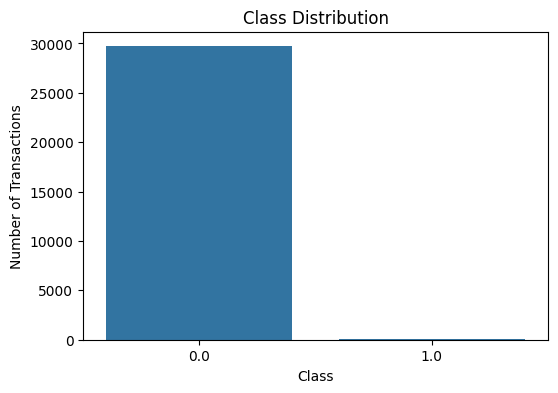

In [ ]:
# Visualise class imbalance
plt.figure(figsize=(6, 4))

sns.countplot(
    x="Class",
    data=df
)

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Transactions")

plt.show()

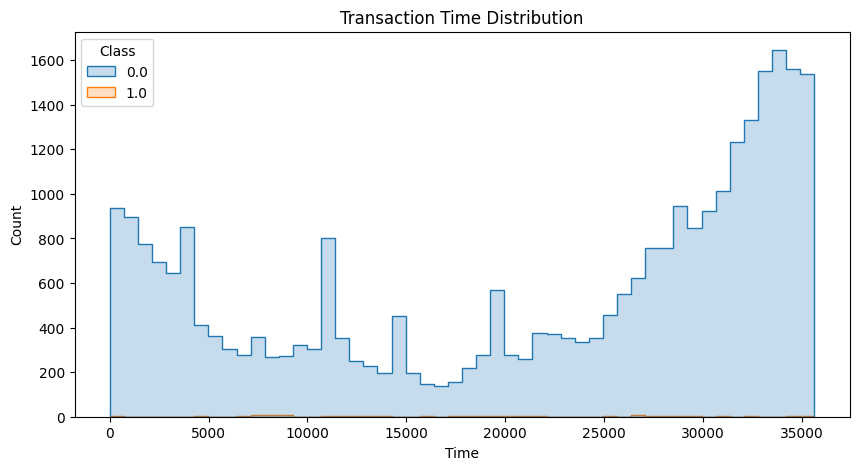

In [ ]:
# understandng time
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="Time",
    hue="Class",
    bins=50,
    element="step"
)

plt.title("Transaction Time Distribution")
plt.show()

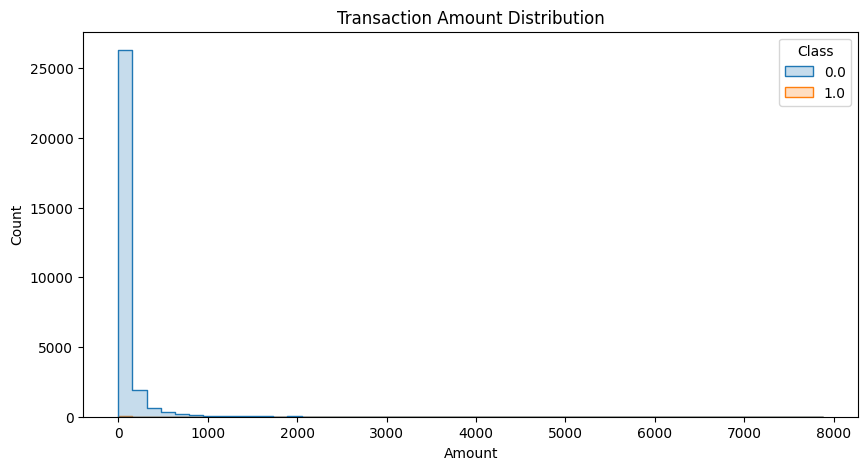

In [ ]:
# understanding transaction amount
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="Amount",
    hue="Class",
    bins=50,
    element="step"
)

plt.title("Transaction Amount Distribution")
plt.show()

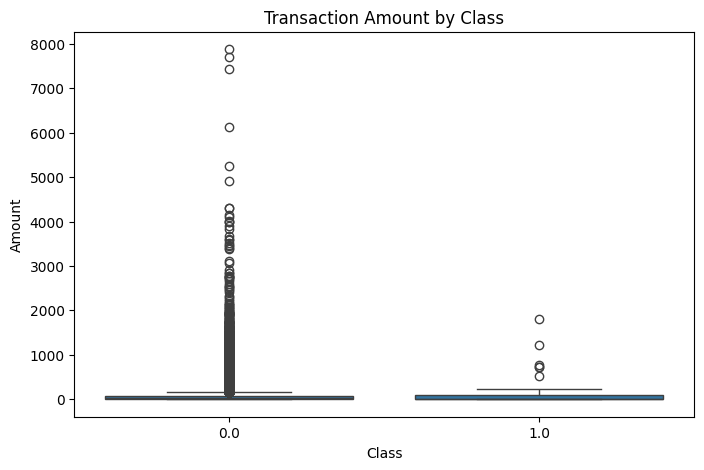

In [ ]:
# compare normal vs froud amount
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="Class",
    y="Amount",
    data=df
)

plt.title("Transaction Amount by Class")

plt.show()

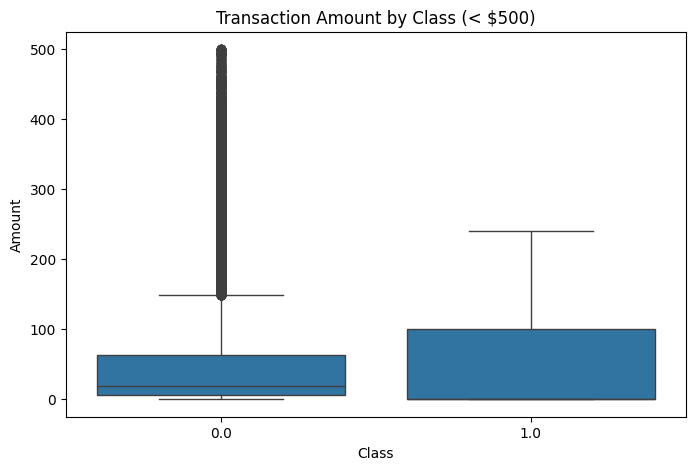

In [ ]:
# for in a range
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="Class",
    y="Amount",
    data=df[df["Amount"] < 500]
)

plt.title("Transaction Amount by Class (< $500)")

plt.show()

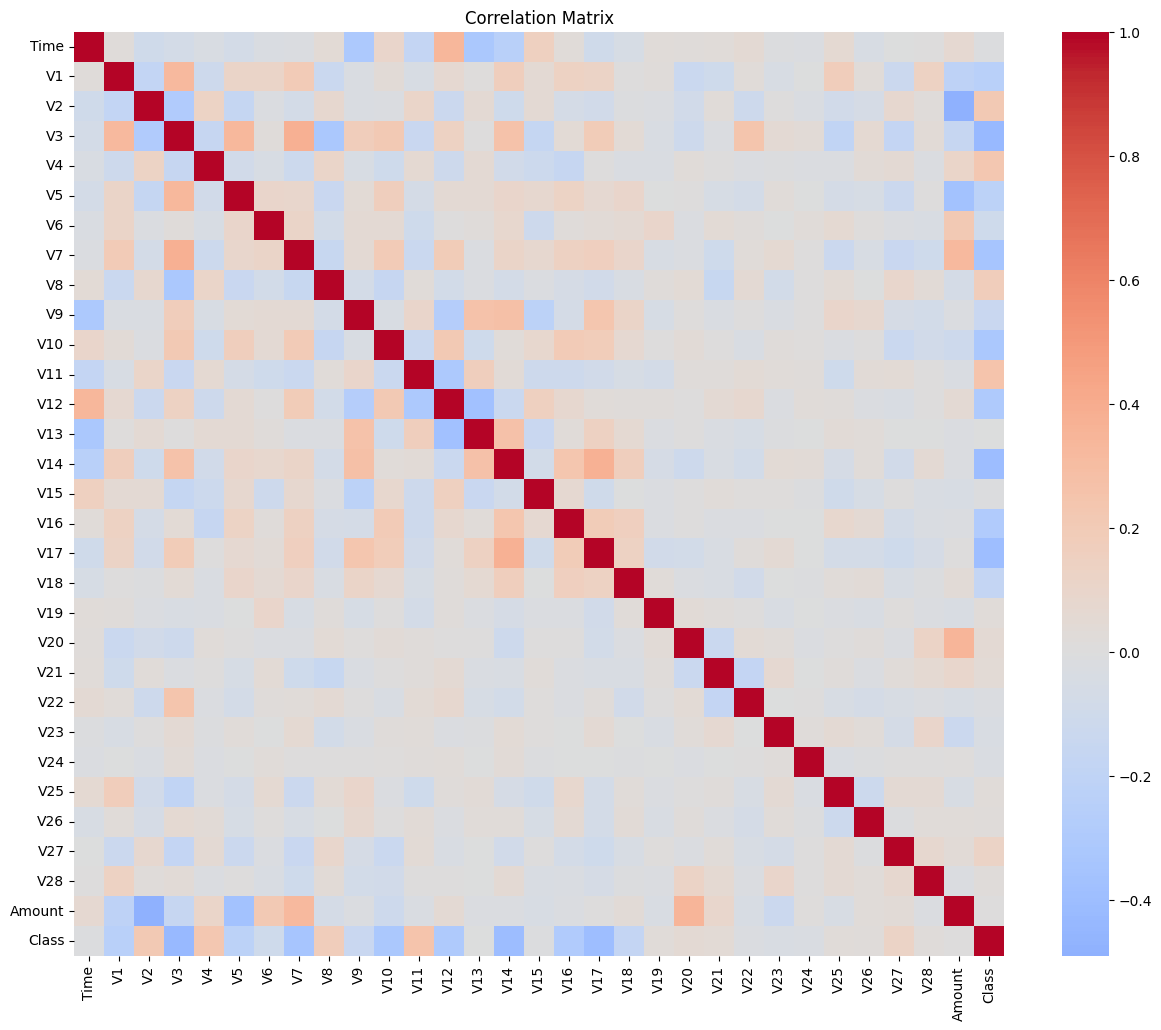

In [ ]:
# correlation analysis
corr = df.corr()
plt.figure(figsize=(15, 12))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")

plt.show()

In [ ]:
# feature correlation
class_corr = df.corr()["Class"].sort_values()

print(class_corr)

V3       -0.428325
V14      -0.404681
V17      -0.399393
V7       -0.339350
V10      -0.324720
V12      -0.299084
V16      -0.287129
V1       -0.240479
V5       -0.217145
V18      -0.172248
V9       -0.145108
V6       -0.104712
V23      -0.030878
V24      -0.025411
V22      -0.022585
Time     -0.011249
V15      -0.008378
V13      -0.002094
Amount    0.004045
V26       0.017657
V28       0.019789
V19       0.023309
V25       0.028382
V21       0.043459
V20       0.054315
V27       0.118511
V8        0.175307
V2        0.217198
V4        0.229981
V11       0.251979
Class     1.000000
Name: Class, dtype: float64


# separate class feature and spliting


In [ ]:
# preparing x and y
x = df.drop("Class", axis=1)

y = df["Class"]

In [ ]:
# train test split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=.20,stratify=y,random_state=42)

**Model1 LogisticRegression baseline**

In [ ]:
baseline_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

In [ ]:
# train baseline
baseline_model.fit(x_train,y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

In [ ]:
y_pred_baseline=baseline_model.predict(x_test)

In [ ]:
#result of baseline model
print(classification_report(
    y_test,y_pred_baseline
))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      5941
         1.0       0.62      0.79      0.70        19

    accuracy                           1.00      5960
   macro avg       0.81      0.89      0.85      5960
weighted avg       1.00      1.00      1.00      5960



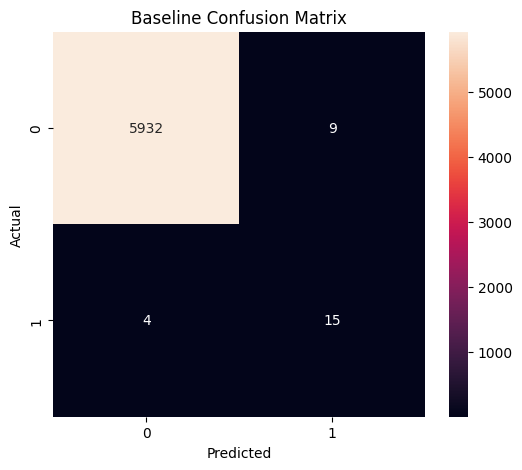

In [ ]:
# confusion metrix
cm = confusion_matrix(
    y_test,
    y_pred_baseline
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Baseline Confusion Matrix")

plt.show()


weighted class model





In [ ]:
weighted_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])

In [ ]:
#Training the model
weighted_model.fit(x_train,y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [ ]:
# predicting
y_pred_weighted=weighted_model.predict(x_test)

**result**


In [ ]:
print(classification_report(y_test,y_pred_weighted))

              precision    recall  f1-score   support

         0.0       1.00      0.99      0.99      4754
         1.0       0.25      0.89      0.40        18

    accuracy                           0.99      4772
   macro avg       0.63      0.94      0.69      4772
weighted avg       1.00      0.99      0.99      4772



# SMOTE model

In [ ]:
smote_lr = Pipeline([
    ("scaler", StandardScaler()),

    ("smote", SMOTE(
        random_state=42
    )),

    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

In [ ]:
smote_lr.fit(x_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('smote', SMOTE(random_state=42)),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

In [ ]:
# prediction
y_pred_smote = smote_lr.predict(x_test)

In [ ]:
#Result
print(classification_report(
    y_test,
    y_pred_smote
))

              precision    recall  f1-score   support

         0.0       1.00      0.98      0.99      5941
         1.0       0.15      0.95      0.26        19

    accuracy                           0.98      5960
   macro avg       0.58      0.97      0.63      5960
weighted avg       1.00      0.98      0.99      5960



In [ ]:
# comparision table
def evaluate_predictions(y_true, y_pred, y_prob):

    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_prob),
        "PR-AUC": average_precision_score(y_true, y_prob)
    }

In [ ]:
# get prob
prob_baseline = baseline_model.predict_proba(x_test)[:, 1]

prob_weighted = weighted_model.predict_proba(x_test)[:, 1]

prob_smote = smote_lr.predict_proba(x_test)[:, 1]

In [ ]:
# comparision table
comparison = pd.DataFrame({
    "Baseline": evaluate_predictions(
        y_test,
        y_pred_baseline,
        prob_baseline
    ),

    "Class Weight": evaluate_predictions(
        y_test,
        y_pred_weighted,
        prob_weighted
    ),

    "SMOTE": evaluate_predictions(
        y_test,
        y_pred_smote,
        prob_smote
    )
})

comparison

,Baseline,Class Weight,SMOTE
Accuracy,0.997819,0.981544,0.983221
Precision,0.625000,0.141732,0.153846
Recall,0.789474,0.947368,0.947368
F1,0.697674,0.246575,0.264706
ROC-AUC,0.991655,0.969667,0.972741
PR-AUC,0.858569,0.694786,0.716387


# precision recall curve

In [ ]:
# for precision
precision, recall, thresholds = precision_recall_curve(
    y_test,
    prob_smote
)

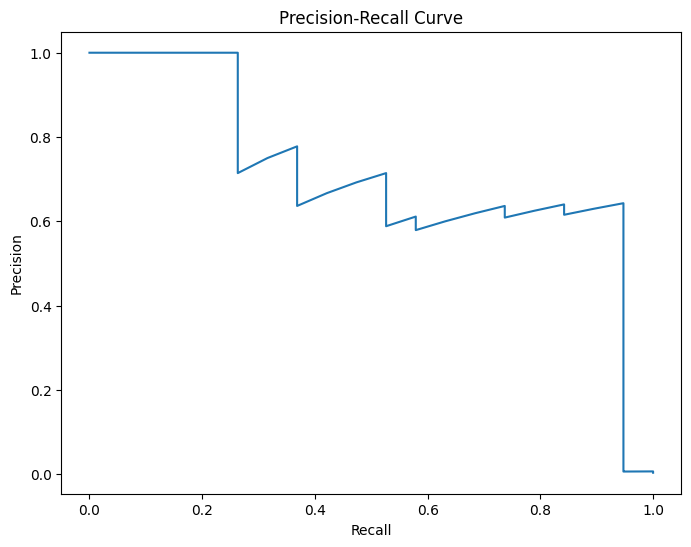

In [ ]:
plt.figure(figsize=(8, 6))

plt.plot(
    recall,
    precision
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.show()

# Random forest model


In [ ]:
# with baseline data
rf=RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

In [ ]:
#training
rf.fit(x_train,y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [ ]:
# predicting
y_pred_rf=rf.predict(x_test)

In [ ]:
print(classification_report(y_test,y_pred_rf))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      5941
         1.0       0.85      0.89      0.87        19

    accuracy                           1.00      5960
   macro avg       0.92      0.95      0.94      5960
weighted avg       1.00      1.00      1.00      5960



# Random forest with class weight




In [ ]:
rf_weighted = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

In [ ]:
rf_weighted.fit(x_train, y_train)

RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

In [ ]:
#predicting
y_pred_rf_weighted = rf_weighted.predict(x_test)

In [ ]:
# result
print(classification_report(
    y_test,
    y_pred_rf_weighted
))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      5941
         1.0       0.90      0.95      0.92        19

    accuracy                           1.00      5960
   macro avg       0.95      0.97      0.96      5960
weighted avg       1.00      1.00      1.00      5960



# Random forest with SMOTE

In [ ]:
smote_rf = Pipeline([
    (
        "smote",
        SMOTE(random_state=42)
    ),

    (
        "model",
        RandomForestClassifier(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        )
    )
])

In [ ]:
#training the model
smote_rf.fit(x_train, y_train)


Pipeline(steps=[('smote', SMOTE(random_state=42)),
                ('model', RandomForestClassifier(n_jobs=-1, random_state=42))])

In [ ]:
#predicting
y_pred_smote_rf = smote_rf.predict(x_test)

In [ ]:
#Result
print(classification_report(
    y_test,
    y_pred_smote_rf
))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      5941
         1.0       0.86      0.95      0.90        19

    accuracy                           1.00      5960
   macro avg       0.93      0.97      0.95      5960
weighted avg       1.00      1.00      1.00      5960



# Final comparision

In [ ]:
#get prob
prob_rf = rf.predict_proba(x_test)[:, 1]

prob_rf_weighted = rf_weighted.predict_proba(x_test)[:, 1]

prob_smote_rf = smote_rf.predict_proba(x_test)[:, 1]

In [ ]:
models = {
    "Logistic Regression": (
        y_pred_baseline,
        prob_baseline
    ),

    "Logistic Regression + Class Weight": (
        y_pred_weighted,
        prob_weighted
    ),

    "Logistic Regression + SMOTE": (
        y_pred_smote,
        prob_smote
    ),

    "Random Forest": (
        y_pred_rf,
        prob_rf
    ),

    "Random Forest + Class Weight": (
        y_pred_rf_weighted,
        prob_rf_weighted
    ),

    "Random Forest + SMOTE": (
        y_pred_smote_rf,
        prob_smote_rf
    )
}

In [ ]:
#Final comparision
results = []

for name, (pred, prob) in models.items():

    result = evaluate_predictions(
        y_test,
        pred,
        prob
    )

    result["Model"] = name

    results.append(result)

results_df = pd.DataFrame(results)

results_df = results_df[
    [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC",
        "PR-AUC"
    ]
]

results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression,0.997819,0.625000,0.789474,0.697674,0.991655,0.858569
1,Logistic Regression + Class Weight,0.981544,0.141732,0.947368,0.246575,0.969667,0.694786
2,Logistic Regression + SMOTE,0.983221,0.153846,0.947368,0.264706,0.972741,0.716387
3,Random Forest,0.999161,0.850000,0.894737,0.871795,0.972918,0.925149
4,Random Forest + Class Weight,0.999497,0.900000,0.947368,0.923077,0.972918,0.917512
5,Random Forest + SMOTE,0.999329,0.857143,0.947368,0.900000,0.996195,0.937673


# Threshold tuning



In [ ]:
prob = prob_smote_rf


In [ ]:
# threshold
thresholds_to_test = [
    0.1,
    0.2,
    0.3,
    0.4,
    0.5,
    0.6,
    0.7,
    0.8,
    0.9
]

In [ ]:
threshold_results = []

for threshold in thresholds_to_test:

    pred = (prob >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_test,
            pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            pred,
            zero_division=0
        )
    })

threshold_df = pd.DataFrame(
    threshold_results
)

threshold_df

,Threshold,Precision,Recall,F1
0,0.1,0.486486,0.947368,0.642857
1,0.2,0.750000,0.947368,0.837209
2,0.3,0.782609,0.947368,0.857143
3,0.4,0.782609,0.947368,0.857143
4,0.5,0.857143,0.947368,0.900000
5,0.6,0.900000,0.947368,0.923077
6,0.7,0.900000,0.947368,0.923077
7,0.8,0.900000,0.947368,0.923077
8,0.9,0.894737,0.894737,0.894737


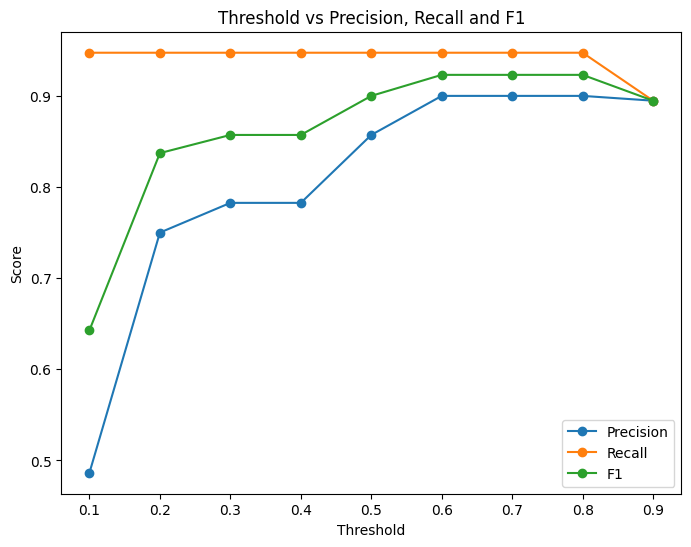

In [ ]:
# plot threshold behavior
plt.figure(figsize=(8, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    marker="o",
    label="F1"
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold vs Precision, Recall and F1")

plt.legend()

plt.show()

# Hyperparameter tuning





In [ ]:
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
#defining
param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

In [ ]:
# tuning pipeline
tuned_smote_rf = Pipeline([
    (
        "smote",
        SMOTE(random_state=42)
    ),

    (
        "model",
        RandomForestClassifier(
            random_state=42,
            n_jobs=-1
        )
    )
])

In [ ]:
search = RandomizedSearchCV(
    tuned_smote_rf,
    param_distributions=param_grid,
    n_iter=20,
    scoring="average_precision",
    cv=5,
    random_state=42,
    n_jobs=-1
)

In [ ]:
# training
search.fit(x_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('smote', SMOTE(random_state=42)),
                                             ('model',
                                              RandomForestClassifier(n_jobs=-1,
                                                                     random_state=42))]),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'model__max_depth': [None, 10, 20],
                                        'model__min_samples_leaf': [1, 2],
                                        'model__min_samples_split': [2, 5],
                                        'model__n_estimators': [100, 200]},
                   random_state=42, scoring='average_precision')

In [ ]:
 # find best parameter
search.best_params_

{'model__n_estimators': 200,
 'model__min_samples_split': 2,
 'model__min_samples_leaf': 1,
 'model__max_depth': None}

In [ ]:
# best cv score
search.best_score_

np.float64(0.9059357465666803)

# Final model

In [ ]:
final_model = search.best_estimator_

In [ ]:
# predict
final_pred = final_model.predict(x_test)

In [ ]:
# get prob
final_prob = final_model.predict_proba(x_test)[:, 1]

# Final evaluation

In [ ]:
print(
    classification_report(
        y_test,
        final_pred
    )
)

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      5941
         1.0       0.86      0.95      0.90        19

    accuracy                           1.00      5960
   macro avg       0.93      0.97      0.95      5960
weighted avg       1.00      1.00      1.00      5960



In [ ]:
final_precision = precision_score(
    y_test,
    final_pred
)

final_recall = recall_score(
    y_test,
    final_pred
)

final_f1 = f1_score(
    y_test,
    final_pred
)

final_roc_auc = roc_auc_score(
    y_test,
    final_prob
)

final_pr_auc = average_precision_score(
    y_test,
    final_prob
)

In [ ]:
#result
print("Precision:", final_precision)
print("Recall:", final_recall)
print("F1:", final_f1)
print("ROC-AUC:", final_roc_auc)
print("PR-AUC:", final_pr_auc)

Precision: 0.8571428571428571
Recall: 0.9473684210526315
F1: 0.9
ROC-AUC: 0.9967885966388788
PR-AUC: 0.9382312340642905


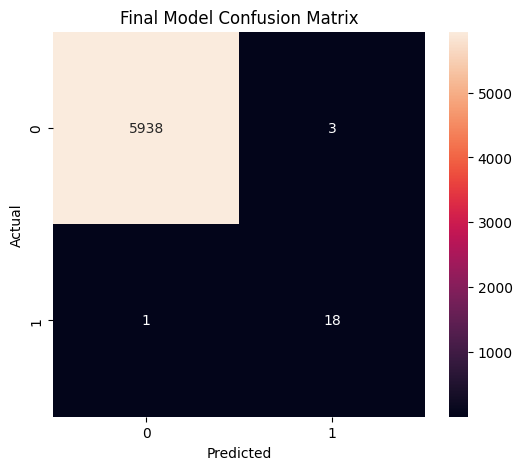

In [ ]:
# final confusion metrix
cm = confusion_matrix(
    y_test,
    final_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title(
    "Final Model Confusion Matrix"
)

plt.show()

In [ ]:
# shaving the model
import joblib

joblib.dump(
    final_model,
    "fraud_detection_model.pkl"
)

['fraud_detection_model.pkl']